# Airbnb Trends

There are many Airbnb listings in New York City to meet the high demand for temporary lodging for travelers, which can be anywhere between a few nights to many months. In this project, we will take a closer look at the New York Airbnb market by combining data from multiple file types like `.csv`, `.tsv`, and `.xlsx`.

Recall that **CSV**, **TSV**, and **Excel** files are three common formats for storing data. 
Three files containing data on 2019 Airbnb listings are available to you:

**data/airbnb_price.csv**
This is a CSV file containing data on Airbnb listing prices and locations.
- **`listing_id`**: unique identifier of listing
- **`price`**: nightly listing price in USD
- **`nbhood_full`**: name of borough and neighborhood where listing is located

**data/airbnb_room_type.xlsx**
This is an Excel file containing data on Airbnb listing descriptions and room types.
- **`listing_id`**: unique identifier of listing
- **`description`**: listing description
- **`room_type`**: Airbnb has three types of rooms: shared rooms, private rooms, and entire homes/apartments

**data/airbnb_last_review.tsv**
This is a TSV file containing data on Airbnb host names and review dates.
- **`listing_id`**: unique identifier of listing
- **`host_name`**: name of listing host
- **`last_review`**: date when the listing was last reviewed

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reading the review.tsv file
airbnb = pd.read_csv('./airbnb_last_review.tsv', sep='\t')
airbnb['last_review'] = pd.to_datetime(airbnb['last_review'], format='%B %d %Y', dayfirst=True)
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25209 entries, 0 to 25208
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   listing_id   25209 non-null  int64         
 1   host_name    25201 non-null  object        
 2   last_review  25209 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 591.0+ KB


In [3]:
airbnb.head()

,listing_id,host_name,last_review
0,2595,Jennifer,2019-05-21
1,3831,LisaRoxanne,2019-07-05
2,5099,Chris,2019-06-22
3,5178,Shunichi,2019-06-24
4,5238,Ben,2019-06-09


Observations:<br>
`host_name` column has some missing values but other 2 columns are complete

### Q: What are the dates of the earliest and most recent reviews?

Store these values as two separate variables with your preferred names.

In [4]:
# Fetch most recent review - using max method
print(airbnb['last_review'].dt.date.max())
# Achieiving same result using iloc
print(airbnb['last_review'].dt.date.sort_values(ascending=False).iloc[0])

2019-07-09
2019-07-09


In [40]:
# answer:
recent_review = airbnb['last_review'].dt.date.max()
print(recent_review)

2019-07-09


In [42]:
# Fetch earliest review - using min method
print(airbnb['last_review'].dt.date.min())
# Achieiving same result using iloc
print(airbnb['last_review'].dt.date.sort_values(ascending=False).iloc[-1])

2019-01-01
2019-01-01


In [41]:
# answer:
earliest_review = airbnb['last_review'].dt.date.min()
print(earliest_review)

2019-01-01


In [8]:
# verifying the result
pd.read_csv('./airbnb_last_review.tsv', sep='\t', parse_dates=["last_review"], date_format='%B %d %Y').sort_values("last_review", ascending=True)

,listing_id,host_name,last_review
12007,21751907,Aura Angelica,2019-01-01
10430,19708955,Karen,2019-01-01
14845,25931882,Can,2019-01-01
7203,13936825,Shlomit,2019-01-01
17123,28813184,Carolyn,2019-01-01
...,...,...,...
23952,34933891,Jessica,2019-07-08
9595,18331097,Jimmy &Cindy,2019-07-08
9505,18173787,Danielle,2019-07-08
17563,29256134,Scott,2019-07-08


### Q: How many of the listings are private rooms? Save this into any variable.

In [9]:
rooms = pd.read_excel('./airbnb_room_type.xlsx')
rooms.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25209 entries, 0 to 25208
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   listing_id   25209 non-null  int64 
 1   description  25199 non-null  object
 2   room_type    25209 non-null  object
dtypes: int64(1), object(2)
memory usage: 591.0+ KB


In [10]:
rooms.head()

,listing_id,description,room_type
0,2595,Skylit Midtown Castle,Entire home/apt
1,3831,Cozy Entire Floor of Brownstone,Entire home/apt
2,5099,Large Cozy 1 BR Apartment In Midtown East,Entire home/apt
3,5178,Large Furnished Room Near B'way,private room
4,5238,Cute & Cozy Lower East Side 1 bdrm,Entire home/apt


Observations:<br>
`description` column has missing values but other 2 columns are complete

In [11]:
rooms['room_type'].value_counts().sort_index()

room_type
ENTIRE HOME/APT    2143
Entire home/apt    8458
PRIVATE ROOM       1867
Private room       7241
SHARED ROOM          97
Shared room         380
entire home/apt    2665
private room       2248
shared room         110
Name: count, dtype: int64

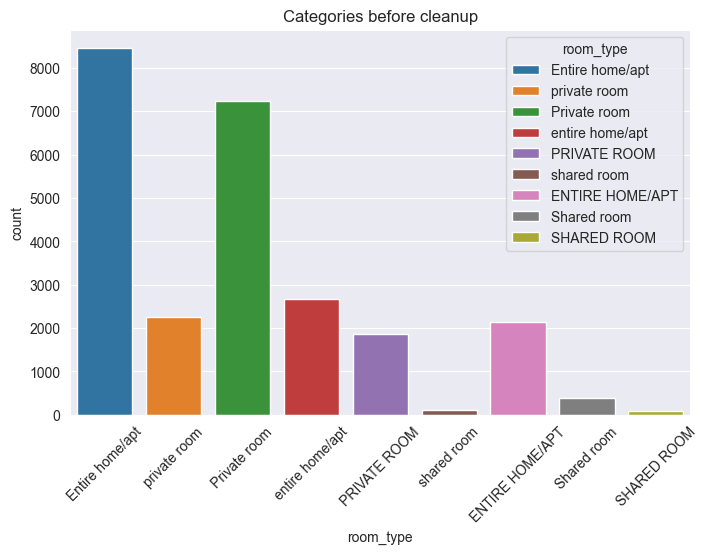

In [12]:
sns.set_style('darkgrid')
plt.subplots(figsize=(8,5))
sns.countplot(data=rooms, x='room_type', hue='room_type', legend=True)
plt.title("Categories before cleanup")
plt.xticks(rotation=45)
plt.show()

Observations:<br>
The `room_types` column will have to be made consistent. 

There are no observed spellng mistakes , we need to make only the formatting consistent.

In [14]:
# Checking trailing & leading whitespaces in the column
rooms[rooms['room_type'].str.startswith(" ")]

rooms[rooms['room_type'].str.endswith(" ")]


,listing_id,description,room_type


In [15]:
rooms['room_type'] = rooms['room_type'].str.lower()
rooms.head()


,listing_id,description,room_type
0,2595,Skylit Midtown Castle,entire home/apt
1,3831,Cozy Entire Floor of Brownstone,entire home/apt
2,5099,Large Cozy 1 BR Apartment In Midtown East,entire home/apt
3,5178,Large Furnished Room Near B'way,private room
4,5238,Cute & Cozy Lower East Side 1 bdrm,entire home/apt


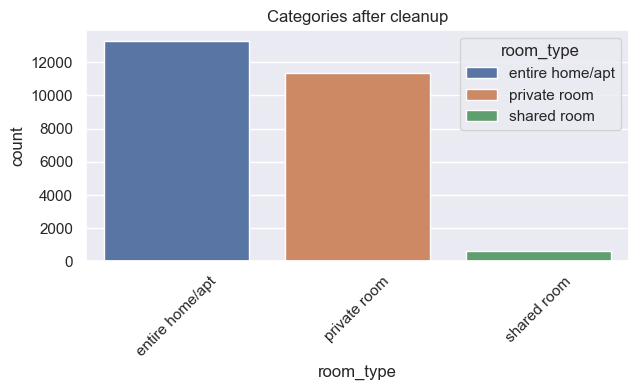

In [33]:
sns.set_style('darkgrid')
plt.subplots(figsize=(7,3))
sns.countplot(data=rooms, x='room_type', hue='room_type', legend=True)
plt.title("Categories after cleanup")
plt.xticks(rotation=45)
plt.show()

In [17]:
room_count_pvt = (rooms['room_type'].value_counts()['private room'])
print(f"The no. of private rooms is {room_count_pvt}")

The no. of private rooms is 11356


### Q: What is the average listing price? 

Round to the nearest two decimal places and save into a variable.

In [36]:
# Loading the dataframe
prices = pd.read_csv('./airbnb_price.csv')
prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25209 entries, 0 to 25208
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   listing_id   25209 non-null  int64 
 1   price        25209 non-null  object
 2   nbhood_full  25209 non-null  object
dtypes: int64(1), object(2)
memory usage: 591.0+ KB


Observations:<br>
No missing values. The `prices` column will have to be converted into int dtype. But first the dollars string will need to be truncated 

In [37]:
prices.head()

,listing_id,price,nbhood_full
0,2595,225 dollars,"Manhattan, Midtown"
1,3831,89 dollars,"Brooklyn, Clinton Hill"
2,5099,200 dollars,"Manhattan, Murray Hill"
3,5178,79 dollars,"Manhattan, Hell's Kitchen"
4,5238,150 dollars,"Manhattan, Chinatown"


In [38]:
prices['price'] = prices['price'].str.replace(' dollars' , '').astype('int')
print(prices.head())
print(prices['price'].info())

   listing_id  price                nbhood_full
0        2595    225         Manhattan, Midtown
1        3831     89     Brooklyn, Clinton Hill
2        5099    200     Manhattan, Murray Hill
3        5178     79  Manhattan, Hell's Kitchen
4        5238    150       Manhattan, Chinatown
<class 'pandas.core.series.Series'>
RangeIndex: 25209 entries, 0 to 25208
Series name: price
Non-Null Count  Dtype
--------------  -----
25209 non-null  int64
dtypes: int64(1)
memory usage: 197.1 KB
None


In [39]:
prices_avg = prices["price"].mean().round(2)
print(prices_avg)

141.78


### Q: Combine the new variables into one DataFrame called `review_dates` with four columns in the following order: <br>
`first_reviewed`, `last_reviewed`, `nb_private_rooms`, and `avg_price`. 

The DataFrame should only contain one row of values.

In [28]:

pd.DataFrame({"a":[1,2,4,None],"b":[11,12,13,14]})


,a,b
0,1.0,11
1,2.0,12
2,4.0,13
3,NaN,14


In [44]:
reviews_ratings = pd.DataFrame({"first_reviewed":[earliest_review],"last_reviewed":[recent_review], "nb_private_rooms":[room_count_pvt], "avg_price":[prices_avg]})
reviews_ratings

,first_reviewed,last_reviewed,nb_private_rooms,avg_price
0,2019-01-01,2019-07-09,11356,141.78


______________________
Further additions -  tbd

In [45]:
rooms.head()

,listing_id,description,room_type
0,2595,Skylit Midtown Castle,entire home/apt
1,3831,Cozy Entire Floor of Brownstone,entire home/apt
2,5099,Large Cozy 1 BR Apartment In Midtown East,entire home/apt
3,5178,Large Furnished Room Near B'way,private room
4,5238,Cute & Cozy Lower East Side 1 bdrm,entire home/apt


In [46]:
prices.head()

,listing_id,price,nbhood_full
0,2595,225,"Manhattan, Midtown"
1,3831,89,"Brooklyn, Clinton Hill"
2,5099,200,"Manhattan, Murray Hill"
3,5178,79,"Manhattan, Hell's Kitchen"
4,5238,150,"Manhattan, Chinatown"


In [54]:
print(rooms['listing_id'].is_unique)
print(prices['listing_id'].is_unique)

True
True


In [58]:
rooms_prices = pd.merge(left=rooms, right=prices, on='listing_id',suffixes=['_pr','_rm'])
rooms_prices.head()

,listing_id,description,room_type,price,nbhood_full
0,2595,Skylit Midtown Castle,entire home/apt,225,"Manhattan, Midtown"
1,3831,Cozy Entire Floor of Brownstone,entire home/apt,89,"Brooklyn, Clinton Hill"
2,5099,Large Cozy 1 BR Apartment In Midtown East,entire home/apt,200,"Manhattan, Murray Hill"
3,5178,Large Furnished Room Near B'way,private room,79,"Manhattan, Hell's Kitchen"
4,5238,Cute & Cozy Lower East Side 1 bdrm,entire home/apt,150,"Manhattan, Chinatown"


In [67]:
major_nbs = rooms_prices['nbhood_full'].value_counts()
# Select top 50 areas for analysis
# major_nbs.head()


Select top 50 neighbourhoods for analysis of prices & reviews

Add column to tag rows to be picked for analysis. Any area in top 50 to be tagged as 'analysis' (column name) - YES / NO

In [69]:
airbnb['listing_id'].is_unique

True

In [76]:
pd.merge(left= rooms_prices, right=airbnb, on='listing_id')

,listing_id,description,room_type,price,nbhood_full,host_name,last_review
0,2595,Skylit Midtown Castle,entire home/apt,225,"Manhattan, Midtown",Jennifer,2019-05-21
1,3831,Cozy Entire Floor of Brownstone,entire home/apt,89,"Brooklyn, Clinton Hill",LisaRoxanne,2019-07-05
2,5099,Large Cozy 1 BR Apartment In Midtown East,entire home/apt,200,"Manhattan, Murray Hill",Chris,2019-06-22
3,5178,Large Furnished Room Near B'way,private room,79,"Manhattan, Hell's Kitchen",Shunichi,2019-06-24
4,5238,Cute & Cozy Lower East Side 1 bdrm,entire home/apt,150,"Manhattan, Chinatown",Ben,2019-06-09
...,...,...,...,...,...,...,...
25204,36425863,Lovely Privet Bedroom with Privet Restroom,private room,129,"Manhattan, Upper East Side",Rusaa,2019-07-07
25205,36427429,No.2 with queen size bed,private room,45,"Queens, Flushing",H Ai,2019-07-07
25206,36438336,Seas The Moment,private room,235,"Staten Island, Great Kills",Ben,2019-07-07
25207,36442252,1B-1B apartment near by Metro,entire home/apt,100,"Bronx, Mott Haven",Blaine,2019-07-07


____
Also analysis on:
- room types vs Areas
- Room types vs prices
- prices vs areas 